##### **공공데이터 약국 활용 예제 : 건강보험심사평가원_약국정보 서비스**

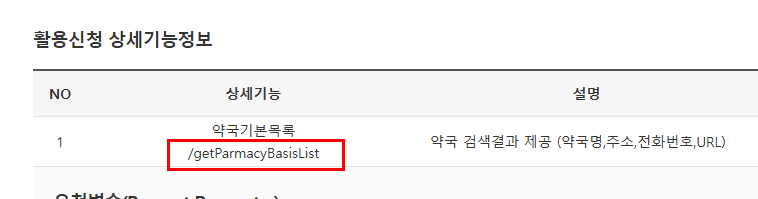

In [ ]:
import requests
from bs4 import BeautifulSoup

service_key = '서비스키입력'

def getParmacy(service_key : str, pageNo : int = 1) -> object:
  """공공 데이터에서 약국 정보를 가져와서 반환하는 함수"""
  # End Point + 활용신청 상세기능정보 > 상세기능에 있는 주소
  url = 'https://apis.data.go.kr/B551182/pharmacyInfoService/getParmacyBasisList'
  params = {
    'ServiceKey' : service_key,
    'pageNo' : pageNo
  }

  try:
    reponse = requests.get(url, params = params)
    
    reponse.raise_for_status()

    # 응답 결과가 xml 파일이어서 변수명이 res_xml로 함(본인 마음으로 지어도 됨)
    res_xml = reponse.text

    # print(reponse.text) # 잘 불러오는지 확인

    soup = BeautifulSoup(res_xml, 'lxml-xml')

    # 전체 약국수
    # totalCount = soup.find('totalCount').text # api 문서에 totalCount(총건수) 제공해서 그거 불러옴 / .text는 값만 가져오기위해
    # print(totalCount)

    # 약국들 정보
    items = soup.find_all('item') # 왜 item? api 문서보면 세부 항목이 item이라 item기준으로 다 긁어올꺼라

    yadmNms = []
    clCdNms = []
    sidoCdNms = []
    sgguCdNms = []
    addrs = []

    for item in items:
      yadmNms.append(item.find('yadmNm').text) # 병원명(약국명)
      clCdNms.append(item.find('clCdNm').text) # 종별 코드명(약국)
      sidoCdNms.append(item.find('sidoCdNm').text) # 시도명
      sgguCdNms.append(item.find('sgguCdNm').text) # 시군구명
      addrs.append(item.find('addr').text) # 주소

      ## print(yadmNms) # 확인용


    # 받아온 데이터를 딕셔너리로 변환
    res_dic = {
      '병원명' : yadmNms,
      '종별코드명' : clCdNms,
      '시도명' : sidoCdNms,
      '시군구명' : sgguCdNms,
      '주소' : addrs
    }
    #최종 데이터가 있는 딕셔너리를 변환
    return res_dic


  except Exception as e:
    print(f"예외 발생 {e}")
    return {}


In [ ]:
# 확인용
print(getParmacy(service_key, 1))

{'병원명': ['서평택약국', '이수약국', '드림호약국', '365 열시약국', '봄한약국', '새싹약국', '세온약국', '현약국', '동아약국', '위드팜필약국'], '종별코드명': ['약국', '약국', '약국', '약국', '약국', '약국', '약국', '약국', '약국', '약국'], '시도명': ['경기', '충북', '인천', '광주', '강원', '서울', '대구', '서울', '부산', '서울'], '시군구명': ['평택시', '영동군', '인천미추홀구', '광주북구', '홍천군', '성북구', '대구동구', '금천구', '부산진구', '서대문구'], '주소': ['경기도 평택시 포승읍 포승향남로 148, 148', '충청북도 영동군 영동읍 난계로 1202, (영동읍)', '인천광역시 미추홀구 용정공원로83번길 59, 드림빌딩 1층 102호 (용현동)', '광주광역시 북구 군왕로 297, 365 열시약국 (각화동)', '강원특별자치도 홍천군 홍천읍 꽃뫼로 54-3, (홍천읍)', '서울특별시 성북구 동소문로7길 4, 1층 (동소문동4가)', '대구광역시 동구 반야월로 205, 동호빌딩 108.109호 (동호동)', '서울특별시 금천구 가산디지털1로 149, 1층 103호 (가산동, 신한이노플렉스)', '부산광역시 부산진구 진남로 554, 270동 A-111, A-112호 (양정동, 양정자이더샵SKVIEW 2단지)', '서울특별시 서대문구 신촌로 91, (창천동)']}


In [46]:
import pandas as pd
import time

df = pd.DataFrame({
  '병원명' : [],
  '종별코드명' : [],
  '시도명' : [],
  '시군구명' : [],
  '주소' : []
})

print(df)

Empty DataFrame
Columns: [병원명, 종별코드명, 시도명, 시군구명, 주소]
Index: []


In [52]:
for i in range(1, 100):
  tmp_df = pd.DataFrame(getParmacy(service_key, i))
  df = pd.concat([df, tmp_df])
  print(f"{i} 페이지가 로딩되었습니다.")
  time.sleep(0.5)

1 페이지가 로딩되었습니다.
2 페이지가 로딩되었습니다.
3 페이지가 로딩되었습니다.
4 페이지가 로딩되었습니다.
5 페이지가 로딩되었습니다.
6 페이지가 로딩되었습니다.
7 페이지가 로딩되었습니다.
8 페이지가 로딩되었습니다.
9 페이지가 로딩되었습니다.
10 페이지가 로딩되었습니다.
11 페이지가 로딩되었습니다.
12 페이지가 로딩되었습니다.
13 페이지가 로딩되었습니다.
14 페이지가 로딩되었습니다.
15 페이지가 로딩되었습니다.
16 페이지가 로딩되었습니다.
17 페이지가 로딩되었습니다.
18 페이지가 로딩되었습니다.
19 페이지가 로딩되었습니다.
20 페이지가 로딩되었습니다.
21 페이지가 로딩되었습니다.
22 페이지가 로딩되었습니다.
23 페이지가 로딩되었습니다.
24 페이지가 로딩되었습니다.
25 페이지가 로딩되었습니다.
26 페이지가 로딩되었습니다.
27 페이지가 로딩되었습니다.
28 페이지가 로딩되었습니다.
29 페이지가 로딩되었습니다.
30 페이지가 로딩되었습니다.
31 페이지가 로딩되었습니다.
32 페이지가 로딩되었습니다.
33 페이지가 로딩되었습니다.
34 페이지가 로딩되었습니다.
35 페이지가 로딩되었습니다.
36 페이지가 로딩되었습니다.
37 페이지가 로딩되었습니다.
38 페이지가 로딩되었습니다.
39 페이지가 로딩되었습니다.
40 페이지가 로딩되었습니다.
41 페이지가 로딩되었습니다.
42 페이지가 로딩되었습니다.
43 페이지가 로딩되었습니다.
44 페이지가 로딩되었습니다.
45 페이지가 로딩되었습니다.
46 페이지가 로딩되었습니다.
47 페이지가 로딩되었습니다.
48 페이지가 로딩되었습니다.
49 페이지가 로딩되었습니다.
50 페이지가 로딩되었습니다.
51 페이지가 로딩되었습니다.
52 페이지가 로딩되었습니다.
53 페이지가 로딩되었습니다.
54 페이지가 로딩되었습니다.
55 페이지가 로딩되었습니다.
56 페이지가 로딩되었습니다.
57 페이지가 로딩되었습니다.
58 페이지가 로딩되었습니다.
59 페이지가 로딩되었습니다.
60 페이지

In [ ]:
# 인덱스 번호 초기화
df = df.reset_index(drop=True)

In [48]:
# csv파일로 저장
df.to_csv('약국 목록.csv', index=False, encoding='utf-8-sig')

In [49]:
# csv 파일 읽어오기
df2 = pd.read_csv('약국 목록.csv', encoding='utf-8')
print(df2)

         병원명 종별코드명 시도명    시군구명  \
0      서평택약국    약국  경기     평택시   
1       이수약국    약국  충북     영동군   
2      드림호약국    약국  인천  인천미추홀구   
3   365 열시약국    약국  광주    광주북구   
4       봄한약국    약국  강원     홍천군   
5       새싹약국    약국  서울     성북구   
6       세온약국    약국  대구    대구동구   
7        현약국    약국  서울     금천구   
8       동아약국    약국  부산    부산진구   
9     위드팜필약국    약국  서울    서대문구   
10  명동 더서울약국    약국  서울      중구   
11      행운약국    약국  서울     중랑구   
12     행복한약국    약국  충남     당진시   
13     새서울약국    약국  서울     구로구   
14    북가좌수약국    약국  서울    서대문구   
15     더조은약국    약국  서울     강동구   
16     큰동의약국    약국  부산    부산진구   
17     즐거운약국    약국  경기   안산상록구   
18      땅콩약국    약국  강원     원주시   
19     새로운약국    약국  경기   성남중원구   
20     둔산탑약국    약국  대전    대전서구   
21      초록약국    약국  경기     시흥시   
22    문산보룡약국    약국  경기     파주시   
23  청담장수 한약국    약국  서울     강남구   
24      대도약국    약국  서울     종로구   
25   메디팜정연약국    약국  서울     강남구   
26      진선약국    약국  서울     강남구   
27      국민약국    약국  서울     강서구   
28     더현대약국  

In [50]:
# 경기에 있는 약국 수를 조회
print(f"경기에 있는 약국 수 : {len(df.loc[df['시도명'] == '경기'])}")

경기에 있는 약국 수 : 6


In [51]:
# 결측치가 있는지 확인 : None, NaN, NaT
df.replace("", None)
print(df.isnull().sum())

병원명      0
종별코드명    0
시도명      0
시군구명     0
주소       0
dtype: int64
